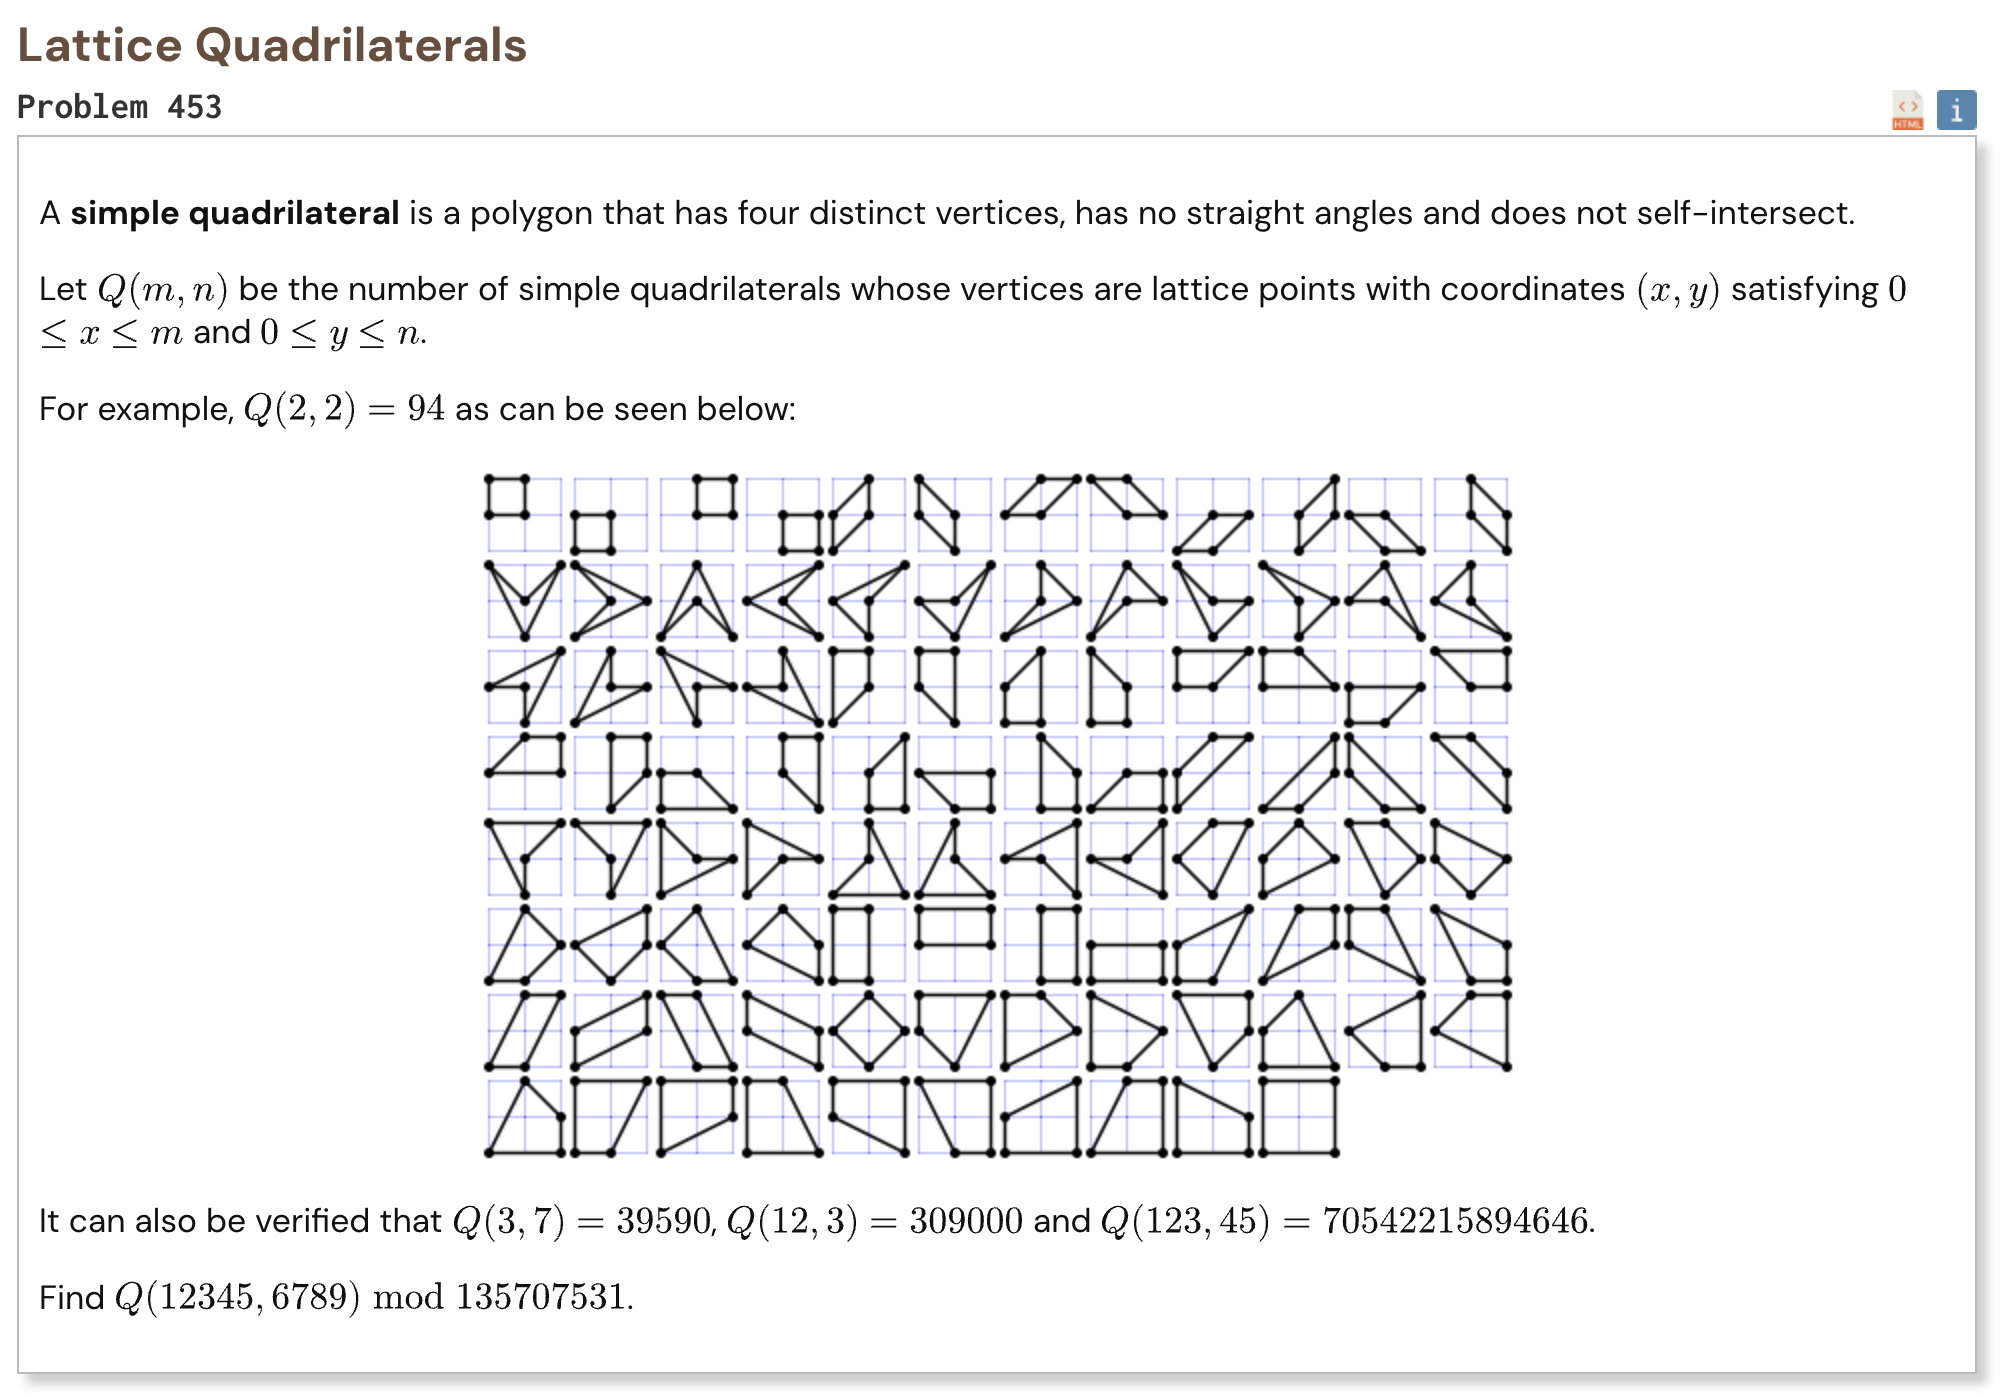

## Initial approach

-   start from every possible set of four lattice points in the rectangle
-   remove sets where at least three points lie on the same straight line
-   use gcd to count lattice points lying between the endpoints of each segment
-   four points in convex position give one simple quadrilateral while a point inside a triangle gives three
-   use Pick's theorem to count the interior lattice points of all possible triangles
-   compute the total triangle boundary contribution and total doubled area contribution separately
-   group segments and triangles by their horizontal and vertical displacement instead of checking individual points
-   combine all counts and take the required modulo at the end

In [1]:
%%time

from math import gcd, comb

M = 12345
N = 6789
MOD = 135707531

points = (M + 1) * (N + 1)

collinear_three = 0
collinear_four = 0
segment_sum = 0
area_sum = 0

for dx in range(1, M + 1):
    count = (N + 1) * (M + 1 - dx)
    g = dx

    collinear_three += count * (g - 1)
    collinear_four += count * (g - 1) * (g - 2) // 2
    segment_sum += count * g

for dy in range(1, N + 1):
    count = (M + 1) * (N + 1 - dy)
    g = dy

    collinear_three += count * (g - 1)
    collinear_four += count * (g - 1) * (g - 2) // 2
    segment_sum += count * g

for dx in range(1, M + 1):
    width_positions = M + 1 - dx
    dx2 = dx * dx

    for dy in range(1, N + 1):
        height_positions = N + 1 - dy
        g = gcd(dx, dy)

        segment_count = 2 * width_positions * height_positions

        collinear_three += segment_count * (g - 1)
        collinear_four += segment_count * (g - 1) * (g - 2) // 2
        segment_sum += segment_count * g

        dy2 = dy * dy

        exact_box_area = (
            dx2
            + dy2
            + 11 * dx2 * dy2
            - g * g
        ) // 3

        area_sum += (
            width_positions
            * height_positions
            * exact_box_area
        )

bad_sets = (
    (points - 3) * collinear_three
    - 3 * collinear_four
)

boundary_sum = (
    points * segment_sum
    - (
        2 * comb(points, 2)
        + 6 * collinear_three
        + 4 * collinear_four
    )
)

result = (
    comb(points, 4)
    - bad_sets
    + 2 * comb(points, 3)
    - 2 * collinear_three
    + area_sum
    - boundary_sum
) % MOD

print("Result:", result)

Result: 104354107
CPU times: user 1min 16s, sys: 498 ms, total: 1min 16s
Wall time: 1min 17s
